# Analisi di `transactions_simple_spatial_train.csv`

Dataset sintetico generato dall'esperimento **`simple_spatial`**: ogni cliente
appartiene a un cluster esplicito che ne definisce il livello di spesa
(`importo`), i merchant preferiti, i codici `cocau` e il **tasso di gap**
tra transazioni. Le quattro classi (`famiglia_giorno`, `giovane_sera`,
`altospendente`, `mattiniero_utenze`) si distinguono quindi su variabili
*spaziali* (importo / merchant / cocau) più la frequenza temporale.

Obiettivi del notebook:
1. esplorare la distribuzione di ogni variabile (globale e per cluster);
2. costruire feature aggregate **per cliente** e proiettarle in 2D con
   **PCA** e **t-SNE**, colorando per cluster di verità.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 60)

In [2]:
def find_repo_root(start: Path) -> Path:
    """Risale le cartelle finché trova la radice del repo (data/ + config.toml)."""
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "config.toml").exists():
            return p
    return start

ROOT = find_repo_root(Path.cwd())
CSV = ROOT / "data" / "transactions_simple_spatial_train.csv"

# Nomi colonna canonici (src/constant.py -> DataConfig)
CLIENT, CLUSTER, TS = "client_id", "cluster", "timestamp"
AMOUNT, MERCHANT, COCAU = "importo", "merchant", "cocau"

df = pd.read_csv(CSV)
df[TS] = pd.to_datetime(df[TS], unit="s")
print("File:", CSV)
print("Righe x colonne:", df.shape)
df.head()

File: /home/julien/Documents/python-proj/embeddingclient/data/transactions_simple_spatial_train.csv
Righe x colonne: (286150, 6)


,client_id,cluster,timestamp,importo,merchant,cocau
0,0,famiglia_giorno,2022-02-05 00:42:31,51.574521,Shell,36
1,0,famiglia_giorno,2022-02-05 05:16:40,-24.700908,Carrefour,8
2,0,famiglia_giorno,2022-02-12 14:59:57,-16.551239,Aldi,8
3,0,famiglia_giorno,2022-02-12 18:46:41,-1.232666,Satispay,101
4,0,famiglia_giorno,2022-02-17 21:33:16,56.645680,Lidl,8


## 0. Panoramica e qualità dei dati

In [3]:
df.info()
print("\nValori mancanti per colonna:")
print(df.isna().sum())
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 286150 entries, 0 to 286149
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   client_id  286150 non-null  int64        
 1   cluster    286150 non-null  str          
 2   timestamp  286150 non-null  datetime64[s]
 3   importo    286150 non-null  float64      
 4   merchant   286150 non-null  str          
 5   cocau      286150 non-null  int64        
dtypes: datetime64[s](1), float64(1), int64(2), str(2)
memory usage: 13.1 MB

Valori mancanti per colonna:
client_id    0
cluster      0
timestamp    0
importo      0
merchant     0
cocau        0
dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
client_id,286150.0,NaN,NaN,NaN,1994.862062,0.0,994.0,1993.0,2990.0,3999.0,1152.544298
cluster,286150,4,famiglia_giorno,126563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,286150,NaN,NaN,NaN,2022-09-14 12:28:47,2020-01-01 03:34:57,2021-09-17 17:42:12,2022-09-22 09:10:00,2023-09-09 05:45:13,2026-09-16 03:13:33,NaN
importo,286150.0,NaN,NaN,NaN,16.874974,-713.400659,13.182853,43.255297,69.834151,195.21826,99.616311
merchant,286150,30,Starbucks,18365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cocau,286150.0,NaN,NaN,NaN,99.750124,7.0,54.0,101.0,123.0,296.0,63.965832


## 1. Bilanciamento dei cluster

Numero di clienti e di transazioni per cluster (la verità di riferimento).

,n_clients,n_transactions,tx_per_client
cluster,,,
altospendente,800,40213,50.3
famiglia_giorno,1400,126563,90.4
giovane_sera,1200,83674,69.7
mattiniero_utenze,600,35700,59.5


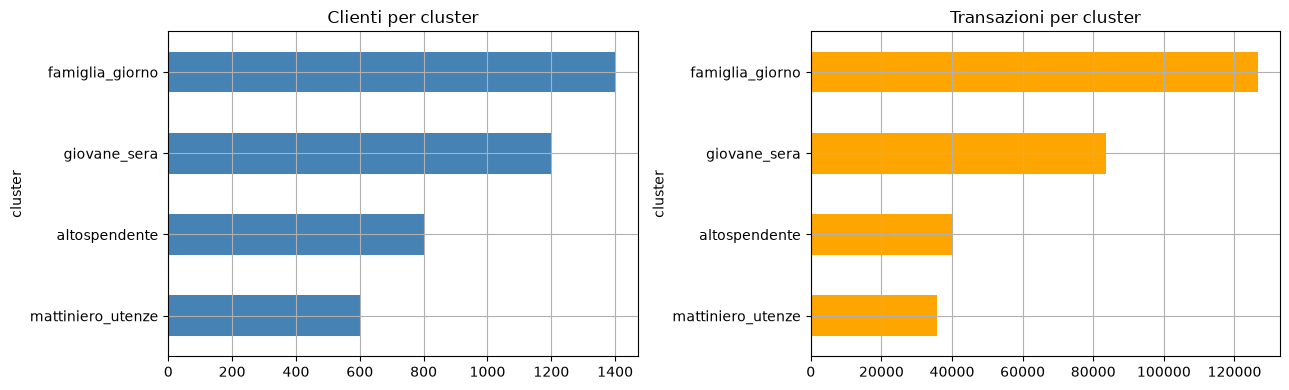

In [4]:
clusters = sorted(df[CLUSTER].unique())
n_clients = df.groupby(CLUSTER)[CLIENT].nunique()
n_tx = df[CLUSTER].value_counts()
summary = pd.DataFrame({"n_clients": n_clients, "n_transactions": n_tx})
summary["tx_per_client"] = (summary["n_transactions"] / summary["n_clients"]).round(1)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_clients.sort_values().plot.barh(ax=ax[0], color="steelblue", title="Clienti per cluster")
n_tx.sort_values().plot.barh(ax=ax[1], color="orange", title="Transazioni per cluster")
plt.tight_layout()

## 2. Distribuzione di `importo`

Il livello di spesa è uno dei discriminanti principali. `altospendente` è
generato come *solo debiti* (importi negativi), gli altri hanno il segno
che emerge dalle normali sottostanti.

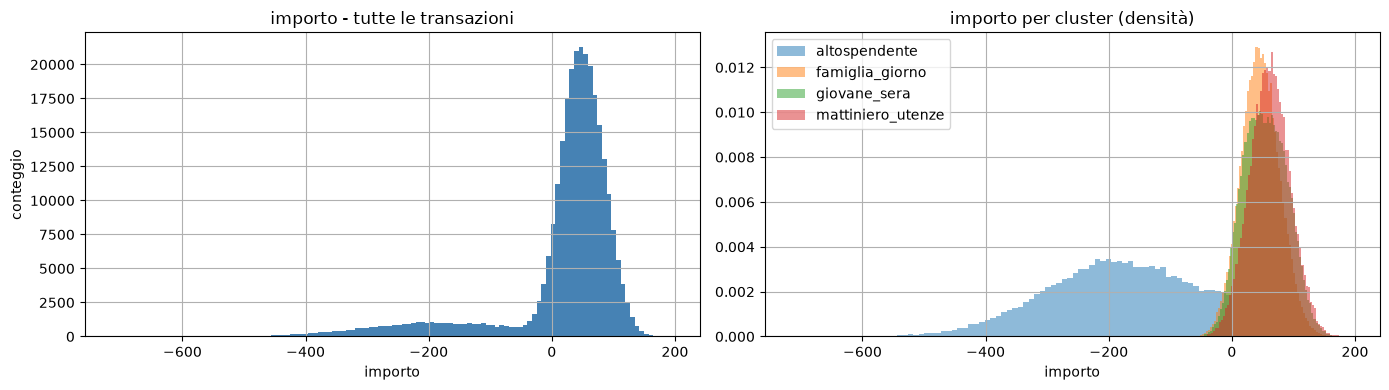

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df[AMOUNT], bins=120, color="steelblue")
ax[0].set(title="importo - tutte le transazioni", xlabel="importo", ylabel="conteggio")
for c in clusters:
    ax[1].hist(df.loc[df[CLUSTER] == c, AMOUNT], bins=80, alpha=0.5, density=True, label=c)
ax[1].set(title="importo per cluster (densità)", xlabel="importo")
ax[1].legend()
plt.tight_layout()

segno,credito (>=0),debito (<0)
cluster,,
altospendente,0.000,1.000
famiglia_giorno,0.934,0.066
giovane_sera,0.945,0.055
mattiniero_utenze,0.970,0.030


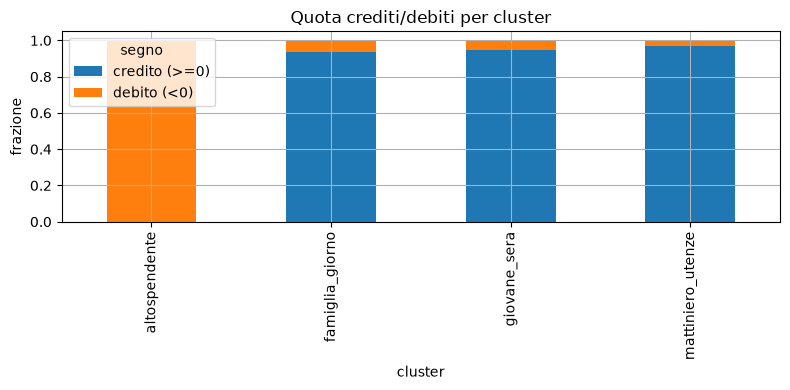

In [6]:
seg = df.assign(segno=np.where(df[AMOUNT] >= 0, "credito (>=0)", "debito (<0)"))
sign = seg.groupby([CLUSTER, "segno"]).size().unstack(fill_value=0)
sign_frac = sign.div(sign.sum(axis=1), axis=0)
display(sign_frac.round(3))
sign_frac.plot.bar(stacked=True, figsize=(8, 4), title="Quota crediti/debiti per cluster")
plt.ylabel("frazione")
plt.tight_layout()

## 3. Variabili categoriche: `merchant` e `cocau`

I pool di merchant (e quindi i `cocau` associati) sono specifici per cluster:
è la parte *spaziale* del segnale.

merchant distinti: 30 | cocau distinti: 47


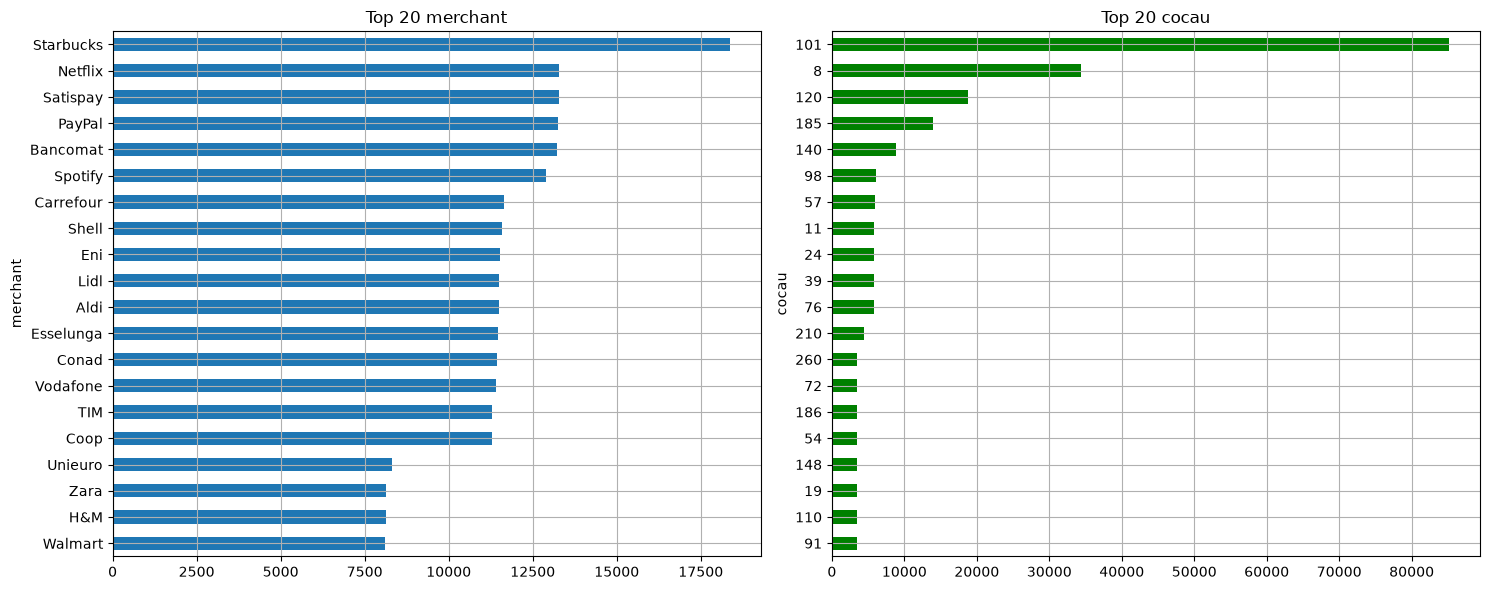

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
df[MERCHANT].value_counts().head(20).sort_values().plot.barh(ax=ax[0], title="Top 20 merchant")
df[COCAU].value_counts().head(20).sort_values().plot.barh(ax=ax[1], color="green", title="Top 20 cocau")
plt.tight_layout()
print("merchant distinti:", df[MERCHANT].nunique(), "| cocau distinti:", df[COCAU].nunique())

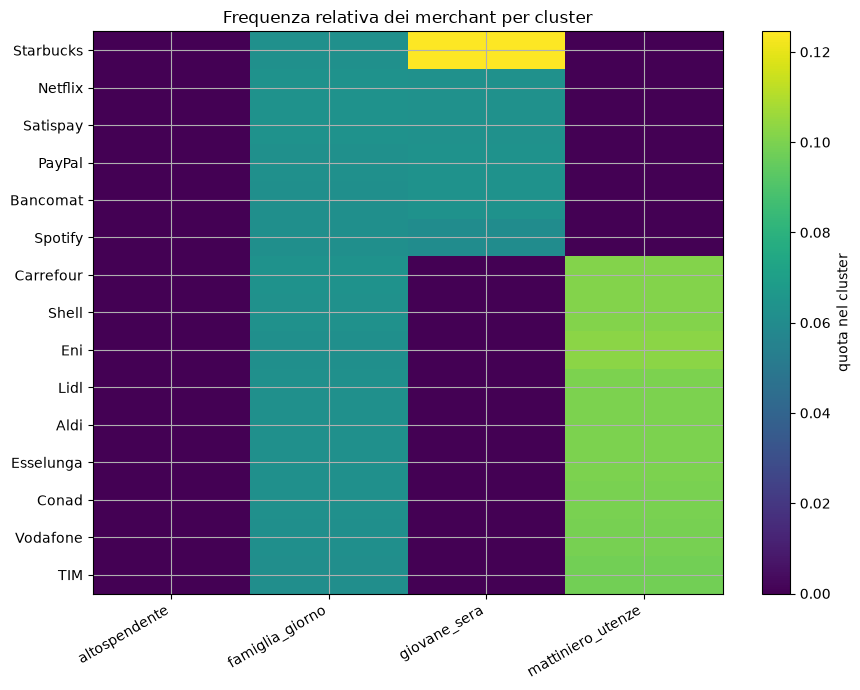

In [8]:
# Frequenza relativa dei merchant più comuni dentro ogni cluster
ct = pd.crosstab(df[MERCHANT], df[CLUSTER], normalize="columns")
top = df[MERCHANT].value_counts().head(15).index
ct = ct.loc[top]
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(ct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=30, ha="right")
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
ax.set_title("Frequenza relativa dei merchant per cluster")
fig.colorbar(im, ax=ax, label="quota nel cluster")
plt.tight_layout()

## 4. Variabili temporali

Per costruzione l'**ora del giorno** e il **giorno della settimana** sono
uniformi (non informativi): il segnale temporale vive solo nel **gap** tra
transazioni consecutive (`delta_t`), esponenziale con tasso `gap_lambda`
specifico per cluster.

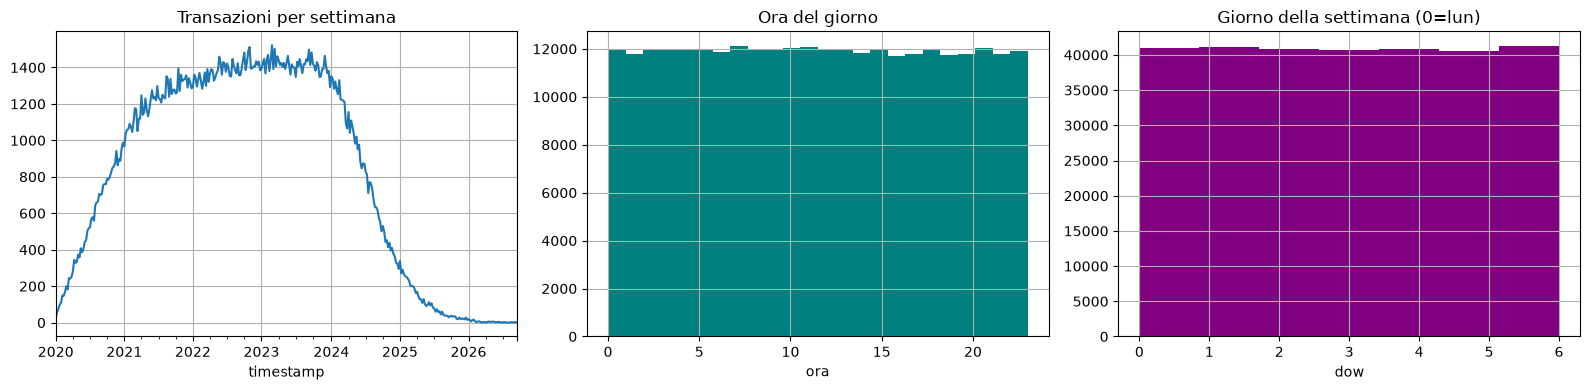

In [9]:
df = df.sort_values([CLIENT, TS])
df["delta_t_days"] = df.groupby(CLIENT)[TS].diff().dt.total_seconds() / 86400.0

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df.set_index(TS).resample("W").size().plot(ax=ax[0], title="Transazioni per settimana")
ax[1].hist(df[TS].dt.hour, bins=24, color="teal")
ax[1].set(title="Ora del giorno", xlabel="ora")
ax[2].hist(df[TS].dt.dayofweek, bins=7, color="purple")
ax[2].set(title="Giorno della settimana (0=lun)", xlabel="dow")
plt.tight_layout()

,mean,median,std
cluster,,,
altospendente,11.99,8.34,11.97
famiglia_giorno,3.98,2.76,3.99
giovane_sera,7.01,4.85,6.99
mattiniero_utenze,8.99,6.21,8.96


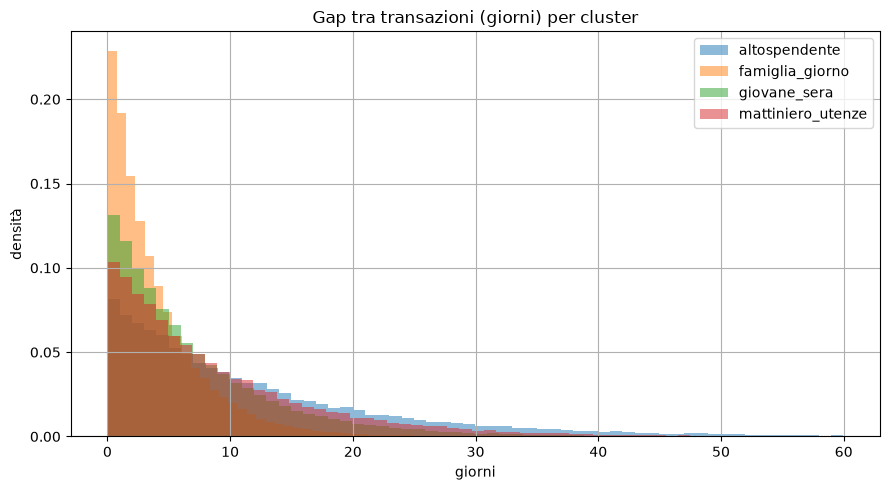

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for c in clusters:
    gap = df.loc[df[CLUSTER] == c, "delta_t_days"].dropna()
    ax.hist(gap[gap < 60], bins=60, alpha=0.5, density=True, label=c)
ax.set(title="Gap tra transazioni (giorni) per cluster", xlabel="giorni", ylabel="densità")
ax.legend()
plt.tight_layout()

df.groupby(CLUSTER)["delta_t_days"].agg(["mean", "median", "std"]).round(2)

## 5. Transazioni per cliente

count    4000.000000
mean       71.537500
std        25.987332
min         5.000000
25%        53.000000
50%        69.000000
75%        88.000000
max       167.000000
dtype: float64

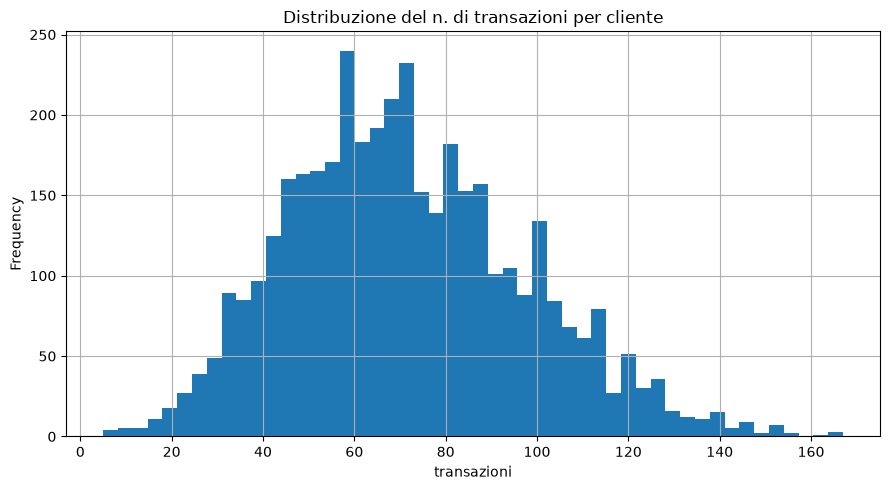

In [11]:
tx_per_client = df.groupby(CLIENT).size()
ax = tx_per_client.plot.hist(bins=50, title="Distribuzione del n. di transazioni per cliente")
ax.set_xlabel("transazioni")
plt.tight_layout()
tx_per_client.describe()

## 6. Proiezione dei clienti (PCA & t-SNE)

I cluster sono definiti a livello di **cliente**, non di singola transazione.
Aggreghiamo quindi ogni cliente in un vettore di feature:

* statistiche su `importo` (media, std, mediana, |importo|, frazione di debiti);
* statistiche sul gap temporale (`gap_mean_days`, `gap_std_days`);
* numero di merchant / cocau distinti;
* istogramma normalizzato sui merchant e cocau più frequenti (top 15).

Dopo standardizzazione proiettiamo in 2D.

In [12]:
g = df.groupby(CLIENT)
num_feats = pd.DataFrame({
    "n_tx": g.size(),
    "amount_mean": g[AMOUNT].mean(),
    "amount_std": g[AMOUNT].std().fillna(0.0),
    "amount_median": g[AMOUNT].median(),
    "abs_amount_mean": g[AMOUNT].apply(lambda s: s.abs().mean()),
    "frac_negative": g[AMOUNT].apply(lambda s: (s < 0).mean()),
    "gap_mean_days": g["delta_t_days"].mean(),
    "gap_std_days": g["delta_t_days"].std(),
    "n_unique_merchant": g[MERCHANT].nunique(),
    "n_unique_cocau": g[COCAU].nunique(),
})

TOPM = df[MERCHANT].value_counts().head(15).index
TOPC = df[COCAU].value_counts().head(15).index
merch_hist = pd.crosstab(df[CLIENT], df[MERCHANT])[TOPM]
merch_hist = merch_hist.div(merch_hist.sum(axis=1).replace(0, 1), axis=0).add_prefix("m_")
cocau_hist = pd.crosstab(df[CLIENT], df[COCAU])[TOPC]
cocau_hist = cocau_hist.div(cocau_hist.sum(axis=1).replace(0, 1), axis=0).add_prefix("c_")

feats = num_feats.join(merch_hist).join(cocau_hist).fillna(0.0)
labels = g[CLUSTER].first().loc[feats.index]
print("Matrice feature per cliente:", feats.shape)
feats.head()

Matrice feature per cliente: (4000, 40)


,n_tx,amount_mean,amount_std,amount_median,abs_amount_mean,frac_negative,gap_mean_days,gap_std_days,n_unique_merchant,n_unique_cocau,m_Starbucks,m_Netflix,m_Satispay,m_PayPal,m_Bancomat,m_Spotify,m_Carrefour,m_Shell,m_Eni,m_Lidl,m_Aldi,m_Esselunga,m_Conad,m_Vodafone,m_TIM,c_101,c_8,c_120,c_185,c_140,c_98,c_57,c_11,c_24,c_39,c_76,c_210,c_260,c_72,c_186
client_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,100,50.422267,32.493521,50.252855,51.861508,0.070000,4.090852,3.884165,16,13,0.082474,0.103093,0.061856,0.020619,0.051546,0.061856,0.061856,0.041237,0.082474,0.092784,0.092784,0.020619,0.082474,0.072165,0.072165,0.588235,0.282353,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035294,0.023529,0.070588,0.0
1,84,55.537102,35.344082,52.749593,56.615193,0.059524,6.371781,7.136522,15,19,0.292683,0.073171,0.121951,0.268293,0.073171,0.170732,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.000000,0.083333,0.000000,0.187500,0.062500,0.062500,0.145833,0.062500,0.208333,0.104167,0.000000,0.000000,0.000000,0.0
2,37,61.488612,35.933973,53.892121,61.488612,0.000000,8.118477,5.362003,13,16,0.500000,0.142857,0.214286,0.000000,0.000000,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.041667,0.000000,0.125000,0.000000,0.083333,0.083333,0.083333,0.166667,0.291667,0.041667,0.083333,0.000000,0.000000,0.000000,0.0
3,84,56.692235,34.964910,61.629484,59.103946,0.071429,6.488307,5.000039,15,19,0.176471,0.029412,0.176471,0.088235,0.323529,0.205882,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.072727,0.000000,0.072727,0.000000,0.218182,0.072727,0.072727,0.090909,0.163636,0.109091,0.127273,0.000000,0.000000,0.000000,0.0
4,63,-186.670424,103.496459,-195.620763,186.670424,1.000000,9.700666,9.360880,14,12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.434783,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.065217,0.000000,0.000000,0.0


Varianza spiegata cumulata: [0.394 0.705 0.768 0.789 0.806 0.82  0.835 0.848 0.858 0.868]


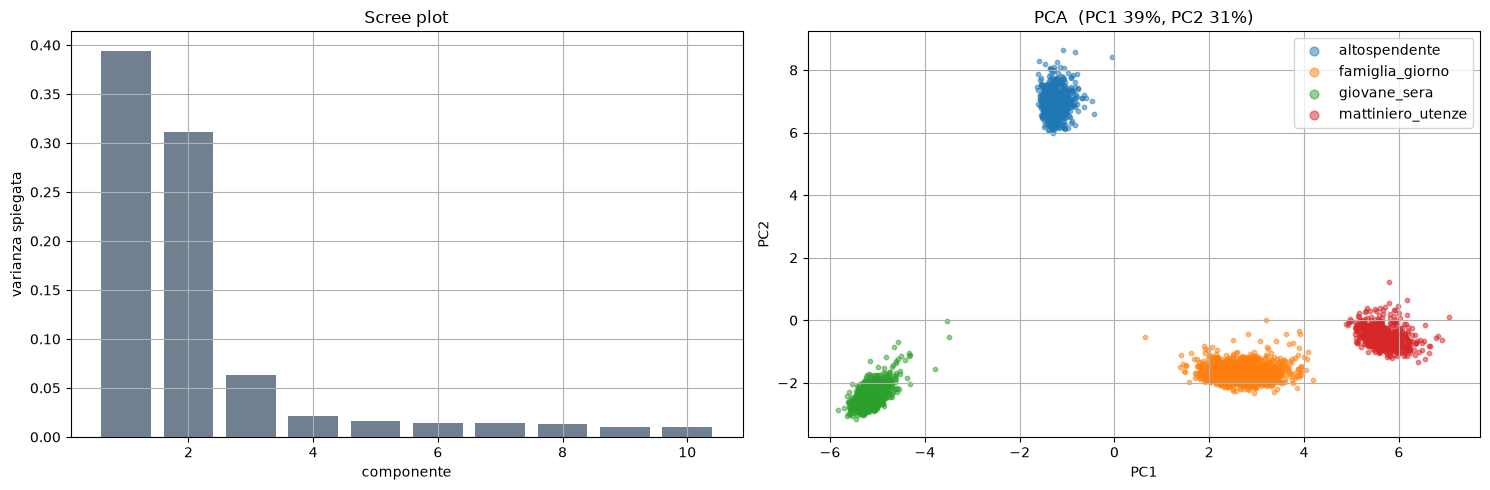

In [13]:
X = StandardScaler().fit_transform(feats.values)
pca = PCA(n_components=10, random_state=0).fit(X)
Xp = pca.transform(X)
evr = pca.explained_variance_ratio_
print("Varianza spiegata cumulata:", np.round(np.cumsum(evr), 3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(1, len(evr) + 1), evr, color="slategray")
ax[0].set(title="Scree plot", xlabel="componente", ylabel="varianza spiegata")
for c in clusters:
    m = labels.values == c
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=10, alpha=0.5, label=c)
ax[1].set(title=f"PCA  (PC1 {evr[0]:.0%}, PC2 {evr[1]:.0%})", xlabel="PC1", ylabel="PC2")
ax[1].legend(markerscale=2)
plt.tight_layout()

In [14]:
# Feature che pesano di più sulle prime due componenti
load = pd.DataFrame(pca.components_[:2].T, index=feats.columns, columns=["PC1", "PC2"])
order = load["PC1"].abs().add(load["PC2"].abs()).sort_values(ascending=False).index
load.loc[order].head(12).round(3)

,PC1,PC2
c_120,-0.100,0.248
m_Starbucks,-0.184,-0.151
amount_std,-0.050,0.273
frac_negative,-0.042,0.277
abs_amount_mean,-0.041,0.277
c_101,0.190,-0.126
amount_mean,0.039,-0.277
amount_median,0.039,-0.276
c_140,-0.196,-0.117
c_185,-0.039,0.272


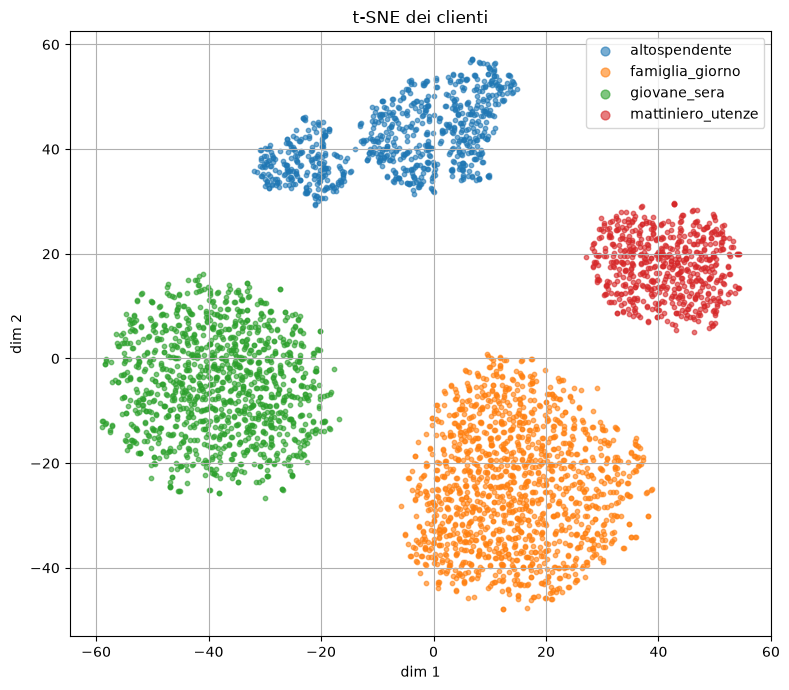

In [15]:
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0)
Xt = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 7))
for c in clusters:
    m = labels.values == c
    ax.scatter(Xt[m, 0], Xt[m, 1], s=10, alpha=0.6, label=c)
ax.set(title="t-SNE dei clienti", xlabel="dim 1", ylabel="dim 2")
ax.legend(markerscale=2)
plt.tight_layout()

## 7. Conclusioni

* I cluster differiscono nettamente per **livello di importo** e **segno**
  (`altospendente` = solo debiti, importi elevati), per i **pool di merchant /
  cocau** e per il **gap temporale** medio tra transazioni.
* Ora-del-giorno e giorno-della-settimana sono ~uniformi: nessun segnale,
  come atteso dal generatore.
* Sulle feature aggregate per cliente, PCA e t-SNE separano visibilmente le
  quattro classi: le prime due componenti catturano gran parte della varianza
  e i merchant/importi sono i loading dominanti.